# IoT Network Intrusion Detection - Data Exploration

This notebook explores the BoT-IoT dataset to understand its characteristics, feature distributions, and class balance.

## Dataset Information
- **Dataset**: BoT-IoT (UNSW Canberra Cyber Range)
- **Files**: 4 CSV files with 10 best features
- **Total Records**: ~3 million
- **Features**: 10 network features
- **Classes**: 5 attack types (Normal, DDoS, DoS, Reconnaissance, Theft)
 

In [1]:
# Import necessary libraries
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

# Add src directory to path
sys.path.append(str(Path().resolve().parent / "src"))

from data_loader import IoTDataLoader

# Set style and ignore warnings
plt.style.use('default')
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

print("Libraries imported successfully!")


Libraries imported successfully!


## 1. Load Dataset


In [2]:
# Load the dataset
data_path = "../data/raw"
loader = IoTDataLoader(data_path)

print("Loading BoT-IoT dataset...")
data = loader.load_data()
print("Dataset loaded successfully!")

# Get dataset information
info = loader.get_data_info()
print(f"\nDataset Information:")
print(f"Total Records: {info['total_records']:,}")
print(f"Total Features: {info['total_features']}")
print(f"Memory Usage: {info['memory_usage']:.2f} MB")
print(f"Number of Classes: {info.get('num_classes', 'Unknown')}")


INFO:data_loader:Loading data from ../data/raw with pattern UNSW_2018_IoT_Botnet_Final_10_Best.csv
INFO:data_loader:Found 1 CSV files: ['../data/raw\\UNSW_2018_IoT_Botnet_Final_10_Best.csv']
INFO:data_loader:Loading ../data/raw\UNSW_2018_IoT_Botnet_Final_10_Best.csv


Loading BoT-IoT dataset...


INFO:data_loader:Loaded 3668522 rows from UNSW_2018_IoT_Botnet_Final_10_Best.csv
INFO:data_loader:Combined dataset shape: (3668522, 20)


Dataset loaded successfully!

Dataset Information:
Total Records: 3,668,522
Total Features: 20
Memory Usage: 1776.51 MB
Number of Classes: 5


## 2. Basic Dataset Information


In [3]:
# Display basic information about the dataset
print("Dataset Shape:", data.shape)
print("\nColumn Names:")
for i, col in enumerate(data.columns, 1):
    print(f"{i:2d}. {col}")

print("\nData Types:")
print(data.dtypes)

print("\nMissing Values:")
missing_values = data.isnull().sum()
print(missing_values[missing_values > 0] if missing_values.sum() > 0 else "No missing values found")


Dataset Shape: (3668522, 20)

Column Names:
 1. Unnamed: 0
 2. pkSeqID
 3. proto
 4. saddr
 5. sport
 6. daddr
 7. dport
 8. seq
 9. stddev
10. N_IN_Conn_P_SrcIP
11. min
12. state_number
13. mean
14. N_IN_Conn_P_DstIP
15. drate
16. srate
17. max
18. attack
19. category
20. subcategory

Data Types:
Unnamed: 0             int64
pkSeqID                int64
proto                 object
saddr                 object
sport                 object
daddr                 object
dport                 object
seq                    int64
stddev               float64
N_IN_Conn_P_SrcIP      int64
min                  float64
state_number           int64
mean                 float64
N_IN_Conn_P_DstIP      int64
drate                float64
srate                float64
max                  float64
attack                 int64
category              object
subcategory           object
dtype: object

Missing Values:
No missing values found


In [ ]:
# Display first few rows
print("First 5 rows of the dataset:")
print(data.head())

print("\nLast 5 rows of the dataset:")
print(data.tail())


First 5 rows of the dataset:


,Unnamed: 0,pkSeqID,proto,saddr,sport,daddr,dport,seq,stddev,N_IN_Conn_P_SrcIP,min,state_number,mean,N_IN_Conn_P_DstIP,drate,srate,max,attack,category,subcategory
0,0,1,tcp,192.168.100.147,49960,192.168.100.7,80,9,0.068909,75,0.000000,1,0.068909,96,14.511893,0.566862,0.137818,1,DoS,HTTP
1,1,2,arp,192.168.100.7,-1,192.168.100.147,-1,10,0.000000,2,0.000131,2,0.000131,1,0.000000,0.000000,0.000131,1,DoS,HTTP
2,2,3,tcp,192.168.100.147,49962,192.168.100.7,80,11,0.064494,75,0.000000,1,0.064494,96,15.505319,0.567549,0.128988,1,DoS,HTTP
3,3,4,tcp,192.168.100.147,49964,192.168.100.7,80,12,0.064189,75,0.000000,1,0.064189,96,15.578993,0.567570,0.128378,1,DoS,HTTP
4,4,5,tcp,192.168.100.147,49966,192.168.100.7,80,13,0.063887,75,0.000000,1,0.063887,96,15.652637,0.567630,0.127774,1,DoS,HTTP



Last 5 rows of the dataset:


,Unnamed: 0,pkSeqID,proto,saddr,sport,daddr,dport,seq,stddev,N_IN_Conn_P_SrcIP,min,state_number,mean,N_IN_Conn_P_DstIP,drate,srate,max,attack,category,subcategory
3668517,3668517,3668518,tcp,192.168.100.150,35064,192.168.100.3,22,81,0.000000,19,0.013165,1,0.013165,19,151.917969,151.917969,0.013165,1,Theft,Keylogging
3668518,3668518,3668519,tcp,192.168.100.150,35066,192.168.100.3,22,82,0.000000,19,0.000574,1,0.000574,19,3484.320557,3484.320557,0.000574,1,Theft,Keylogging
3668519,3668519,3668520,tcp,192.168.100.150,35070,192.168.100.3,22,84,0.000000,19,2.874302,6,2.874302,19,5.566569,4.522837,2.874302,1,Theft,Keylogging
3668520,3668520,3668521,tcp,192.168.100.3,43001,192.168.100.150,4433,85,0.000000,3,0.000003,1,0.000003,1,0.000000,0.000000,0.000003,1,Theft,Keylogging
3668521,3668521,3668522,arp,192.168.100.3,-1,192.168.100.149,-1,10,0.000056,3,0.000080,2,0.000145,2,0.008255,0.008255,0.000272,1,Theft,Keylogging


## 3. Target Variable Analysis


In [5]:
# Analyze the target variable (category)
print("Target Variable Analysis:")
print("=" * 40)

# Class distribution
class_counts = data['category'].value_counts()
class_percentages = data['category'].value_counts(normalize=True) * 100

print("\nClass Distribution:")
for class_name, count in class_counts.items():
    percentage = class_percentages[class_name]
    print(f"{class_name:15s}: {count:8,} ({percentage:6.2f}%)")

print(f"\nTotal Classes: {len(class_counts)}")
print(f"Total Samples: {len(data):,}")


Target Variable Analysis:

Class Distribution:
DDoS           : 1,926,624 ( 52.52%)
DoS            : 1,650,260 ( 44.98%)
Reconnaissance :   91,082 (  2.48%)
Normal         :      477 (  0.01%)
Theft          :       79 (  0.00%)

Total Classes: 5
Total Samples: 3,668,522


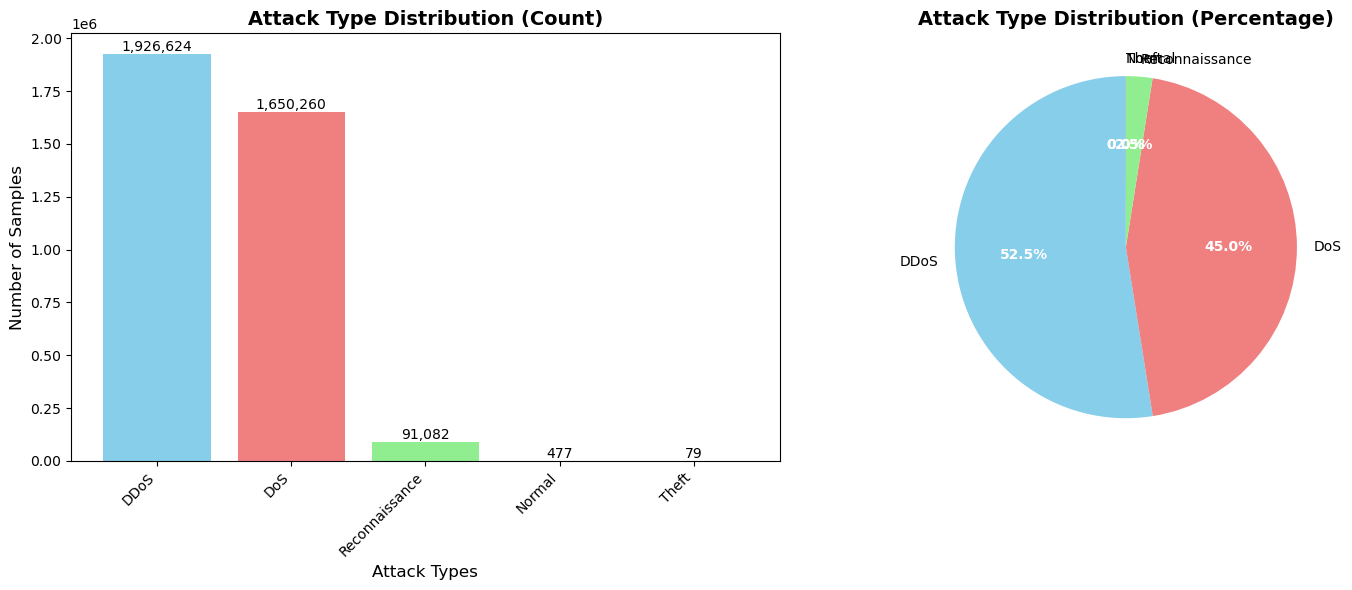

In [6]:
# Create class distribution visualization
plt.figure(figsize=(15, 6))

# Bar chart
plt.subplot(1, 2, 1)
bars = plt.bar(class_counts.index, class_counts.values, 
               color=['skyblue', 'lightcoral', 'lightgreen', 'orange', 'purple'])
plt.title('Attack Type Distribution (Count)', fontsize=14, fontweight='bold')
plt.xlabel('Attack Types', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}', ha='center', va='bottom', fontsize=10)

# Pie chart
plt.subplot(1, 2, 2)
colors = ['skyblue', 'lightcoral', 'lightgreen', 'orange', 'purple']
wedges, texts, autotexts = plt.pie(class_counts.values, labels=class_counts.index, 
                                   autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('Attack Type Distribution (Percentage)', fontsize=14, fontweight='bold')

# Improve text readability
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

plt.tight_layout()
plt.show()


## 4. Feature Analysis


In [ ]:
# Get feature columns (exclude target variable)
feature_columns = [col for col in data.columns if col != 'category']
print(f"Feature columns ({len(feature_columns)}): {feature_columns}")

# Statistical summary of features
print("\nStatistical Summary of Features:")
print("=" * 50)
print(data[feature_columns].describe())


Feature columns (19): ['Unnamed: 0', 'pkSeqID', 'proto', 'saddr', 'sport', 'daddr', 'dport', 'seq', 'stddev', 'N_IN_Conn_P_SrcIP', 'min', 'state_number', 'mean', 'N_IN_Conn_P_DstIP', 'drate', 'srate', 'max', 'attack', 'subcategory']

Statistical Summary of Features:


,Unnamed: 0,pkSeqID,seq,stddev,N_IN_Conn_P_SrcIP,min,state_number,mean,N_IN_Conn_P_DstIP,drate,srate,max,attack
count,3.668522e+06,3.668522e+06,3.668522e+06,3.668522e+06,3.668522e+06,3.668522e+06,3.668522e+06,3.668522e+06,3.668522e+06,3.668522e+06,3.668522e+06,3.668522e+06,3.668522e+06
mean,1.834260e+06,1.834262e+06,1.213204e+05,8.871499e-01,8.253848e+01,1.017540e+00,3.134390e+00,2.231063e+00,9.245168e+01,4.455046e-01,2.955111e+00,3.020015e+00,9.998700e-01
std,1.059011e+06,1.059011e+06,7.579428e+04,8.037139e-01,2.439739e+01,1.483688e+00,1.186971e+00,1.517728e+00,1.817643e+01,6.028863e+01,7.245425e+02,1.860877e+00,1.140212e-02
min,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,9.171302e+05,9.171312e+05,5.487600e+04,3.001900e-02,6.900000e+01,0.000000e+00,3.000000e+00,1.819670e-01,1.000000e+02,0.000000e+00,1.559700e-01,2.806072e-01,1.000000e+00
50%,1.834260e+06,1.834262e+06,1.177690e+05,7.938960e-01,1.000000e+02,0.000000e+00,4.000000e+00,2.690125e+00,1.000000e+02,0.000000e+00,2.837830e-01,4.009111e+00,1.000000e+00
75%,2.751391e+06,2.751392e+06,1.849300e+05,1.745296e+00,1.000000e+02,2.151138e+00,4.000000e+00,3.565203e+00,1.000000e+02,0.000000e+00,4.882010e-01,4.293582e+00,1.000000e+00
max,3.668521e+06,3.668522e+06,2.622120e+05,2.496763e+00,1.000000e+02,4.980471e+00,1.100000e+01,4.981882e+00,1.000000e+02,5.882353e+04,1.000000e+06,4.999999e+00,1.000000e+00


Numeric Features (10):
 1. seq
 2. stddev
 3. N_IN_Conn_P_SrcIP
 4. min
 5. state_number
 6. mean
 7. N_IN_Conn_P_DstIP
 8. drate
 9. srate
10. max


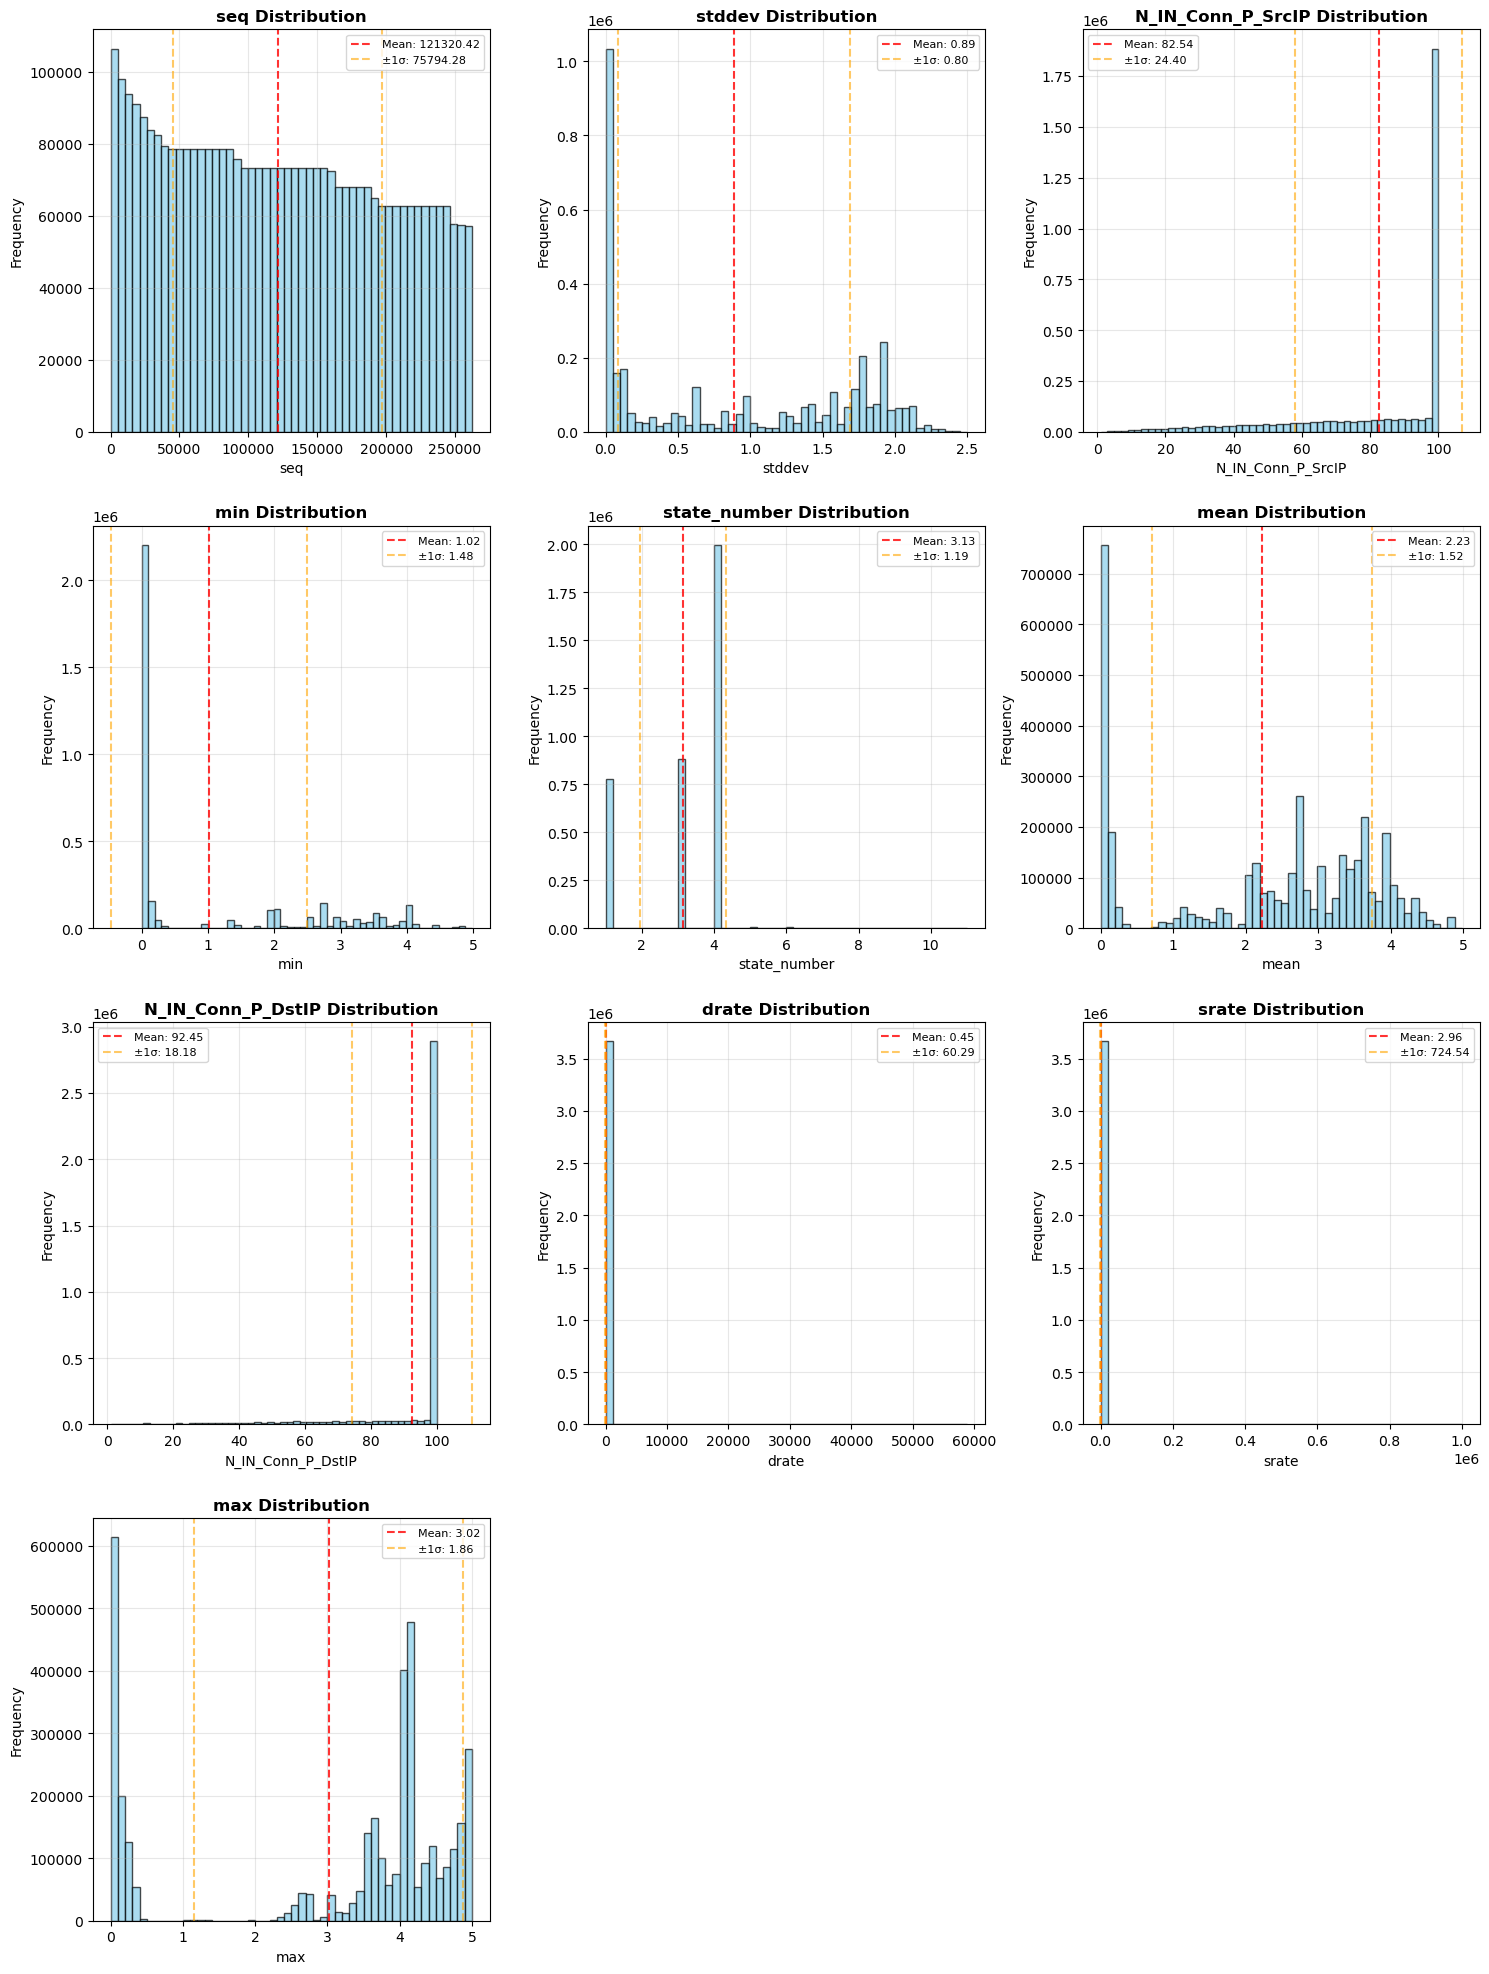

In [8]:
# Identify numeric features for visualization
numeric_features = data.select_dtypes(include=['number']).columns.tolist()
# Remove non-feature columns
exclude_columns = ['Unnamed: 0', 'pkSeqID', 'attack']
numeric_features = [col for col in numeric_features if col not in exclude_columns]

print(f"Numeric Features ({len(numeric_features)}):")
for i, feature in enumerate(numeric_features, 1):
    print(f"{i:2d}. {feature}")

# Create feature distribution plots for numeric features
n_features = len(numeric_features)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

plt.figure(figsize=(15, 5 * n_rows))

for i, feature in enumerate(numeric_features, 1):
    plt.subplot(n_rows, n_cols, i)
    
    # Create histogram
    plt.hist(data[feature], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
    plt.title(f'{feature} Distribution', fontsize=12, fontweight='bold')
    plt.xlabel(feature, fontsize=10)
    plt.ylabel('Frequency', fontsize=10)
    plt.grid(True, alpha=0.3)
    
    # Add statistics
    mean_val = data[feature].mean()
    std_val = data[feature].std()
    plt.axvline(mean_val, color='red', linestyle='--', alpha=0.8, label=f'Mean: {mean_val:.2f}')
    plt.axvline(mean_val + std_val, color='orange', linestyle='--', alpha=0.6, label=f'±1σ: {std_val:.2f}')
    plt.axvline(mean_val - std_val, color='orange', linestyle='--', alpha=0.6)
    plt.legend(fontsize=8)

plt.tight_layout()
plt.show()


## 5. Correlation Analysis


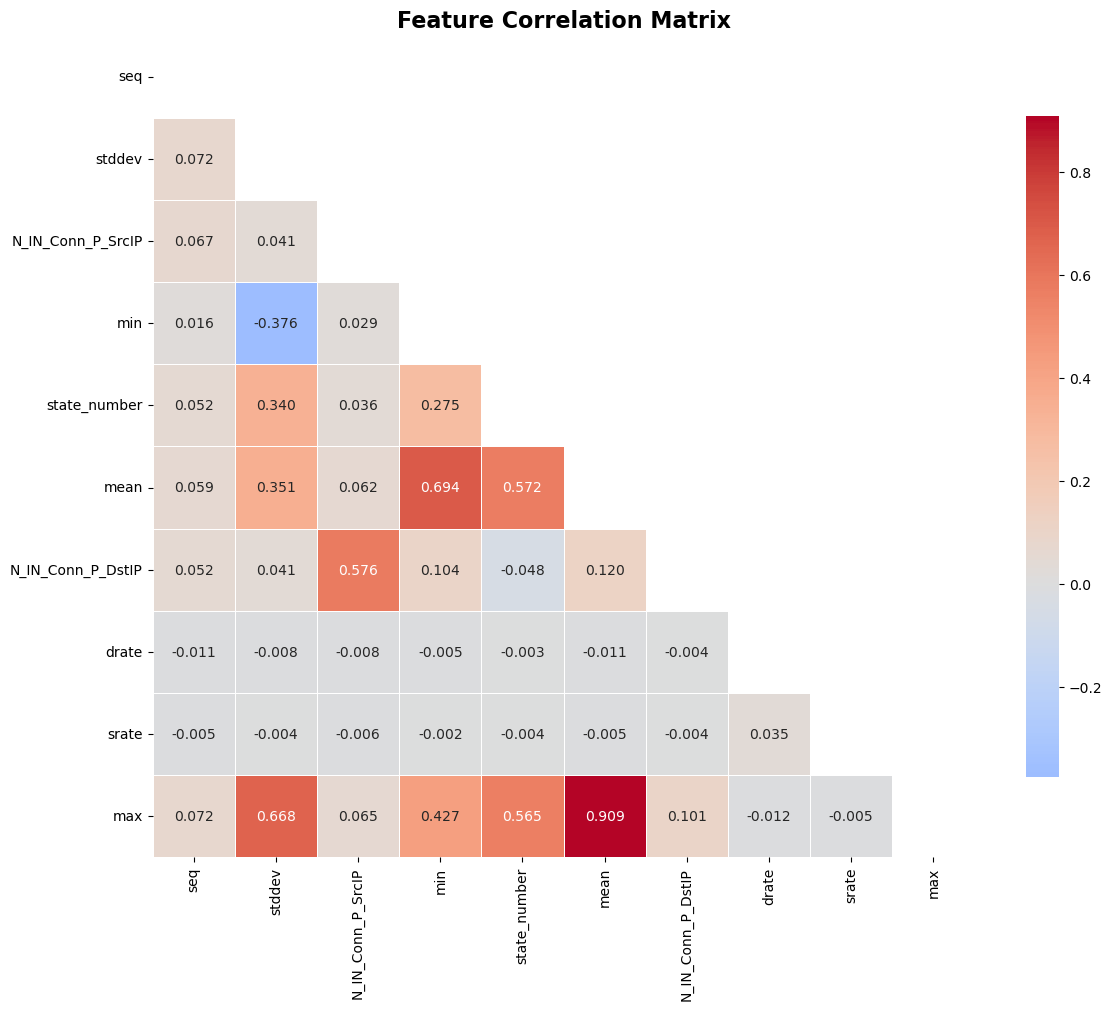


Highly Correlated Feature Pairs (|r| > 0.7):
mean                 <-> max                 :  0.909


In [9]:
# Calculate correlation matrix for numeric features
correlation_matrix = data[numeric_features].corr()

# Create correlation heatmap
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))  # Mask upper triangle

sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": .8}, fmt='.3f')

plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Find highly correlated feature pairs
print("\nHighly Correlated Feature Pairs (|r| > 0.7):")
print("=" * 50)

high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_val = correlation_matrix.iloc[i, j]
        if abs(corr_val) > 0.7:
            high_corr_pairs.append((
                correlation_matrix.columns[i], 
                correlation_matrix.columns[j], 
                corr_val
            ))

if high_corr_pairs:
    for feat1, feat2, corr in high_corr_pairs:
        print(f"{feat1:20s} <-> {feat2:20s}: {corr:6.3f}")
else:
    print("No highly correlated feature pairs found.")


## 6. Attack Pattern Analysis


In [ ]:
# Analyze feature patterns for each attack type
print("Feature Statistics by Attack Type:")
print("=" * 50)

# Group by attack type and calculate statistics
attack_stats = data.groupby('category')[numeric_features].agg(['mean', 'std', 'min', 'max']).round(4)
print(attack_stats)


Feature Statistics by Attack Type:


seq                          stddev               \
                       mean         std min     max    mean     std  min   
category                                                                   
DDoS            123273.9050  73788.1880   1  262168  0.9454  0.7518  0.0   
DoS             125068.5774  75736.5335   1  262212  0.8683  0.8533  0.0   
Normal            8830.3145   8542.0095   1   33724  0.0393  0.1897  0.0   
Reconnaissance   12782.6083   9525.9909   8   37889  0.0021  0.0550  0.0   
Theft               45.6709     22.1468   8      85  0.0000  0.0000  0.0   

                       N_IN_Conn_P_SrcIP                       min          \
                   max              mean      std min  max    mean     std   
category                                                                     
DDoS            2.4968           81.9592  24.2096   1  100  1.3019  1.4911   
DoS             2.4455           84.2264  23.3298   1  100  0.7407  1.4391   
Normal          1.8932           20.4067  21.9830   1   74  0.3138  0.9545   
Reconnaissance  2.0690           64.5757  36.1797   1  100  0.0230  0.1155   
Theft           0.0001           35.9241  15.4246   3   48  0.8534  1.4692   

                            state_number                    mean               \
                min     max         mean     std min max    mean     std  min   
category                                                                        
DDoS            0.0  4.9805       3.0434  1.1911   1   7  2.5496  1.4042  0.0   
DoS             0.0  4.9110       3.2891  1.1027   1   5  1.9815  1.5384  0.0   
Normal          0.0  4.9504       2.8679  1.2790   1   8  0.4994  1.3318  0.0   
Reconnaissance  0.0  3.0833       2.2584  1.8203   1  11  0.0251  0.1289  0.0   
Theft           0.0  4.4388       2.3797  2.2032   1   6  0.8534  1.4692  0.0   

                       N_IN_Conn_P_DstIP                      drate            \
                   max              mean      std min  max     mean       std   
category                                                                        
DDoS            4.9819           99.9074   2.1951   1  100   0.0070    0.0357   
DoS             4.9110           84.2404  23.3200   1  100   0.0050    0.1490   
Normal          4.9671            8.3166   8.2974   1   85  11.0285  133.6432   
Reconnaissance  3.6390           84.0223  29.0036   1  100  17.5958  381.9182   
Theft           4.4388           20.0633   6.5757   1   25  58.6230  400.0723   

                                     srate                                 \
                min         max       mean         std  min           max   
category                                                                    
DDoS            0.0      1.0646     0.5154      0.6062  0.0        7.3394   
DoS             0.0     43.1537     0.4998      1.2561  0.0      203.4053   
Normal          0.0   2178.6492  5943.6992  58124.5573  0.0  1000000.0000   
Reconnaissance  0.0  58823.5273    67.8882   1816.1706  0.0   250000.0000   
Theft           0.0   3484.3206    58.3652    400.1047  0.0     3484.3206   

                   max                       
                  mean     std  min     max  
category                                     
DDoS            3.3490  1.6466  0.0  5.0000  
DoS             2.8020  1.9648  0.0  4.9999  
Normal          0.5385  1.3980  0.0  5.0000  
Reconnaissance  0.0274  0.1630  0.0  4.8208  
Theft           0.8534  1.4692  0.0  4.4388

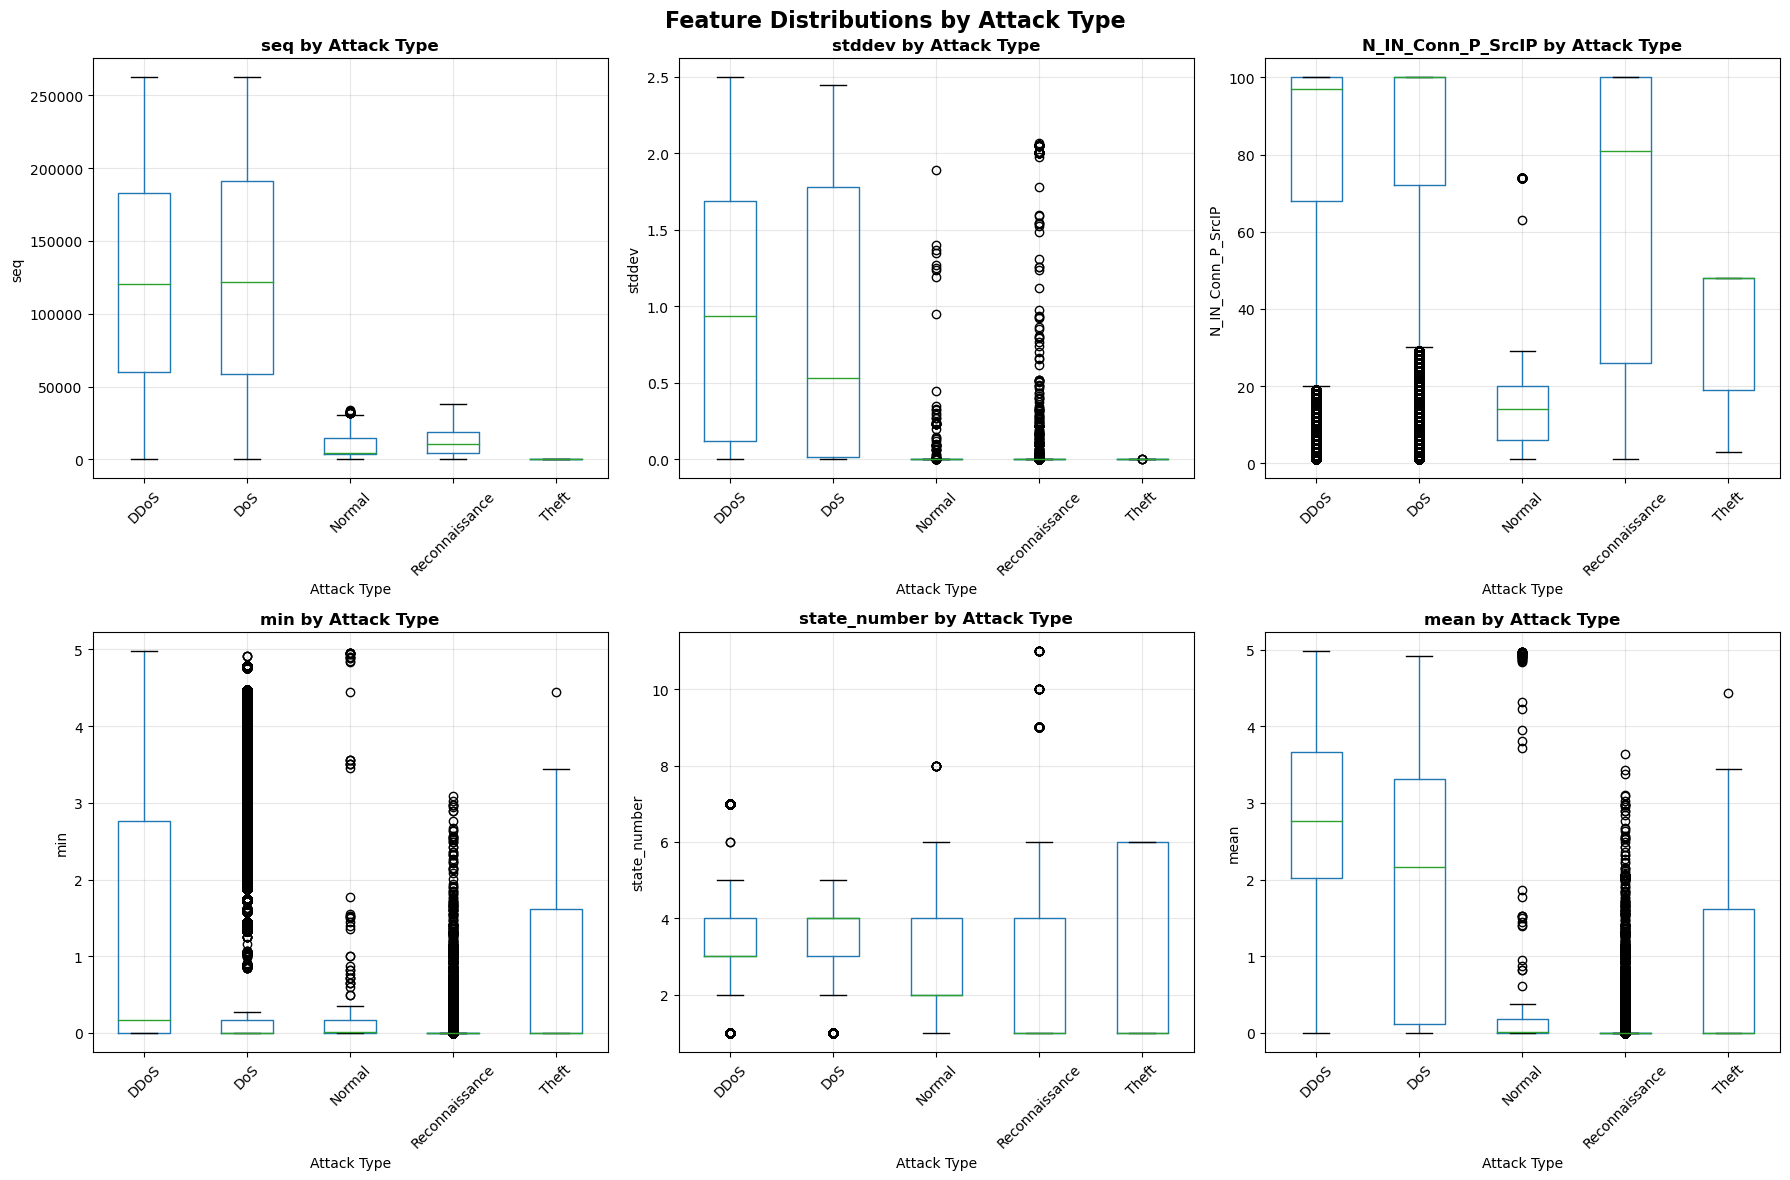

In [11]:
# Create box plots for feature distributions by class (using first 6 features)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

# Select 6 most important features for visualization
important_features = numeric_features[:6]

for i, feature in enumerate(important_features):
    ax = axes[i]
    
    # Create box plot
    data.boxplot(column=feature, by='category', ax=ax)
    ax.set_title(f'{feature} by Attack Type', fontsize=12, fontweight='bold')
    ax.set_xlabel('Attack Type', fontsize=10)
    ax.set_ylabel(feature, fontsize=10)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)

# Remove the automatic title from boxplot
plt.suptitle('Feature Distributions by Attack Type', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


## 7. Data Quality Assessment


In [12]:
# Data quality assessment
print("Data Quality Assessment:")
print("=" * 40)

# Check for duplicates
duplicates = data.duplicated().sum()
print(f"Duplicate rows: {duplicates:,} ({duplicates/len(data)*100:.2f}%)")

# Check for outliers using IQR method
print("\nOutlier Detection (IQR Method):")
outlier_summary = {}

for feature in numeric_features:
    Q1 = data[feature].quantile(0.25)
    Q3 = data[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data[feature] < lower_bound) | (data[feature] > upper_bound)][feature]
    outlier_count = len(outliers)
    outlier_percentage = (outlier_count / len(data)) * 100
    
    outlier_summary[feature] = {
        'count': outlier_count,
        'percentage': outlier_percentage,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound
    }
    
    if outlier_count > 0:
        print(f"{feature:20s}: {outlier_count:8,} outliers ({outlier_percentage:5.1f}%)")

# Check data consistency
print("\nData Consistency Checks:")
print(f"Negative values in numeric features:")
for feature in numeric_features:
    negative_count = (data[feature] < 0).sum()
    if negative_count > 0:
        print(f"  {feature}: {negative_count:,} negative values")

# Memory usage analysis
print(f"\nMemory Usage Analysis:")
print(f"Total memory usage: {data.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"Memory per record: {data.memory_usage(deep=True).sum() / len(data) / 1024:.2f} KB")


Data Quality Assessment:
Duplicate rows: 0 (0.00%)

Outlier Detection (IQR Method):
N_IN_Conn_P_SrcIP   :  110,683 outliers (  3.0%)
state_number        :  784,141 outliers ( 21.4%)
N_IN_Conn_P_DstIP   :  798,222 outliers ( 21.8%)
drate               :  270,243 outliers (  7.4%)
srate               :  274,902 outliers (  7.5%)

Data Consistency Checks:
Negative values in numeric features:

Memory Usage Analysis:
Total memory usage: 1776.51 MB
Memory per record: 0.50 KB


## 8. Summary and Key Insights


In [13]:
# Generate summary insights
print("KEY INSIGHTS FROM DATA EXPLORATION:")
print("=" * 50)

print(f"\n1. Dataset Overview:")
print(f"   • Total records: {len(data):,}")
print(f"   • Total features: {len(feature_columns)}")
print(f"   • Memory usage: {data.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print(f"   • Data quality: {'Good' if duplicates == 0 else 'Issues found'}")

print(f"\n2. Class Distribution:")
for class_name, count in class_counts.items():
    percentage = class_percentages[class_name]
    print(f"   • {class_name:15s}: {percentage:5.1f}% ({count:,} samples)")

print(f"\n3. Feature Characteristics:")
print(f"   • Numeric features: {len(numeric_features)}")
print(f"   • Highly correlated pairs: {len(high_corr_pairs)}")
print(f"   • Duplicate records: {duplicates:,}")

print(f"\n4. Data Quality:")
print(f"   • Missing values: {'None found' if missing_values.sum() == 0 else 'Present'}")
print(f"   • Outliers detected: {sum(1 for v in outlier_summary.values() if v['count'] > 0)} features")

print(f"\n5. Recommendations for Preprocessing:")
print(f"   • Feature scaling required: Yes (due to different scales)")
print(f"   • Class imbalance handling: {'Yes' if max(class_percentages) - min(class_percentages) > 10 else 'No'}")
print(f"   • Outlier treatment: {'Consider capping' if sum(1 for v in outlier_summary.values() if v['count'] > 0) > 0 else 'Not critical'}")

print(f"\n6. Model Training Considerations:")
print(f"   • Dataset size: {'Large' if len(data) > 1000000 else 'Medium'}")
print(f"   • Training time estimate: {'High' if len(data) > 1000000 else 'Medium'}")
print(f"   • Memory requirements: {'High' if data.memory_usage(deep=True).sum() / 1024**2 > 100 else 'Medium'}")

print(f"\nData exploration completed successfully!")
print(f"Ready for preprocessing and model training.")


KEY INSIGHTS FROM DATA EXPLORATION:

1. Dataset Overview:
   • Total records: 3,668,522
   • Total features: 19
   • Memory usage: 1776.5 MB
   • Data quality: Good

2. Class Distribution:
   • DDoS           :  52.5% (1,926,624 samples)
   • DoS            :  45.0% (1,650,260 samples)
   • Reconnaissance :   2.5% (91,082 samples)
   • Normal         :   0.0% (477 samples)
   • Theft          :   0.0% (79 samples)

3. Feature Characteristics:
   • Numeric features: 10
   • Highly correlated pairs: 1
   • Duplicate records: 0

4. Data Quality:
   • Missing values: None found
   • Outliers detected: 5 features

5. Recommendations for Preprocessing:
   • Feature scaling required: Yes (due to different scales)
   • Class imbalance handling: Yes
   • Outlier treatment: Consider capping

6. Model Training Considerations:
   • Dataset size: Large
   • Training time estimate: High
   • Memory requirements: High

Data exploration completed successfully!
Ready for preprocessing and model trainin